# Lab4 Frolova AI

## First task (for first task you can choose between several tasks!)

You need to train you own Variational Autoencoder based on any colorful dataset you could choose (e.g. CIFAR10, CelebA dataset, etc.).

**Requirements to your solution:**

1. Encoder and Decoder realizations using PyTorch framework as we did in the GAN section (basically from scratch).

2. After the training phase, you should provide at least 10 randomly generated images, which should have patterns distinguishable to the human eye. This means the generated images shouldn't be just random noise, but they also don't have to be perfectly generated samples (although this is desirable).

3. Provide comments for each step in your code.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm 
import os

# Проверяем, доступна ли CUDA (видеокарта NVIDIA), иначе используем процессор
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

os.makedirs('./vae_outputs', exist_ok=True)
os.makedirs('./vae_weights', exist_ok=True)

Using device: cpu


In [2]:
batch_size = 128          # Количество картинок за один шаг
learning_rate = 1e-3      # Скорость обучения
latent_dim = 128          # Размерность нашего латентного пространства (вектор z)
num_epochs = 50           # Количество эпох (проходов по всему датасету)
image_size = 32           # CIFAR-10 имеет размер 32x32
image_channels = 3        # CIFAR-10 цветной (RGB)

# Трансформации для данных: превращаем в тензор и нормализуем в диапазон [-1, 1]
# Это стандартная практика для генеративных моделей.
transform = transforms.Compose([
    transforms.ToTensor(),  # Превращает PIL Image (0-255) в тензор (0.0-1.0)
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # (x - 0.5) / 0.5 -> диапазон [-1, 1]
])

# Загружаем тренировочную часть CIFAR-10
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

# Для проверки возьмем небольшую часть тестовой выборки
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:14<00:00, 11.6MB/s] 


In [3]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # ---- Энкодер ----
        # Вход: изображение 3x32x32
        self.encoder = nn.Sequential(
            # Блок 1: 32 -> 16
            nn.Conv2d(image_channels, 32, kernel_size=4, stride=2, padding=1),  # out: 32x16x16
            nn.ReLU(),
            # Блок 2: 16 -> 8
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # out: 64x8x8
            nn.ReLU(),
            # Блок 3: 8 -> 4
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # out: 128x4x4
            nn.ReLU(),
            # Блок 4: 4 -> 2
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), # out: 256x2x2
            nn.ReLU(),
        )

        # Преобразует выход энкодера (256*2*2 = 1024) в вектор mu
        self.fc_mu = nn.Linear(256 * 2 * 2, latent_dim)
        # Преобразует выход энкодера в вектор log_var
        self.fc_log_var = nn.Linear(256 * 2 * 2, latent_dim)

        # ---- Декодер ----
        # Первый слой декодера: из вектора z делаем "прото-изображение" 256x2x2
        self.decoder_fc = nn.Linear(latent_dim, 256 * 2 * 2)

        # Транспонированные свертки для увеличения разрешения
        self.decoder = nn.Sequential(
            # Вход: 256x2x2
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, image_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh() 
        )

    def encode(self, x):
        # Пропускаем через энкодер
        encoded = self.encoder(x)
        # Выпрямляем (flatten) для полносвязных слоев
        flattened = encoded.view(encoded.size(0), -1)
        # Получаем параметры распределения
        mu = self.fc_mu(flattened)
        log_var = self.fc_log_var(flattened)
        return mu, log_var

    def reparameterize(self, mu, log_var):
        """
        Трюк с репараметризацией.
        """
        # Вычисляем стандартное отклонение из логарифма дисперсии
        std = torch.exp(0.5 * log_var)
        # Генерируем случайный шум из N(0,1)
        eps = torch.randn_like(std)
        # Возвращаем сдвинутый и масштабированный шум
        return mu + eps * std

    def decode(self, z):
        # Пропускаем через первый полносвязный слой
        decoded = self.decoder_fc(z)
        # Преобразуем обратно в формат "изображения" (batch, channels, height, width)
        decoded = decoded.view(decoded.size(0), 256, 2, 2)
        # Пропускаем через декодер
        reconstruction = self.decoder(decoded)
        return reconstruction

    def forward(self, x):
        # Прямой проход: кодируем, применяем трюк, декодируем
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        reconstruction = self.decode(z)
        return reconstruction, mu, log_var

loss = mse + kl

In [4]:
def vae_loss(recon_x, x, mu, log_var):
    """
    recon_x: восстановленное изображение
    x: оригинальное изображение
    mu: среднее значение латентного распределения
    log_var: логарифм дисперсии
    """
    recon_loss = F.mse_loss(recon_x, x, reduction='sum') 

    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    total_loss = (recon_loss + kl_loss) / x.size(0)

    return total_loss, recon_loss / x.size(0), kl_loss / x.size(0)

In [5]:
model = VAE(latent_dim=latent_dim).to(device)

# Использую Adam
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print("Model Architecture:")
print(model)

Model Architecture:
VAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
  )
  (fc_mu): Linear(in_features=1024, out_features=128, bias=True)
  (fc_log_var): Linear(in_features=1024, out_features=128, bias=True)
  (decoder_fc): Linear(in_features=128, out_features=1024, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(32, 3, kernel_size=(4,

Reconstructions BEFORE training:


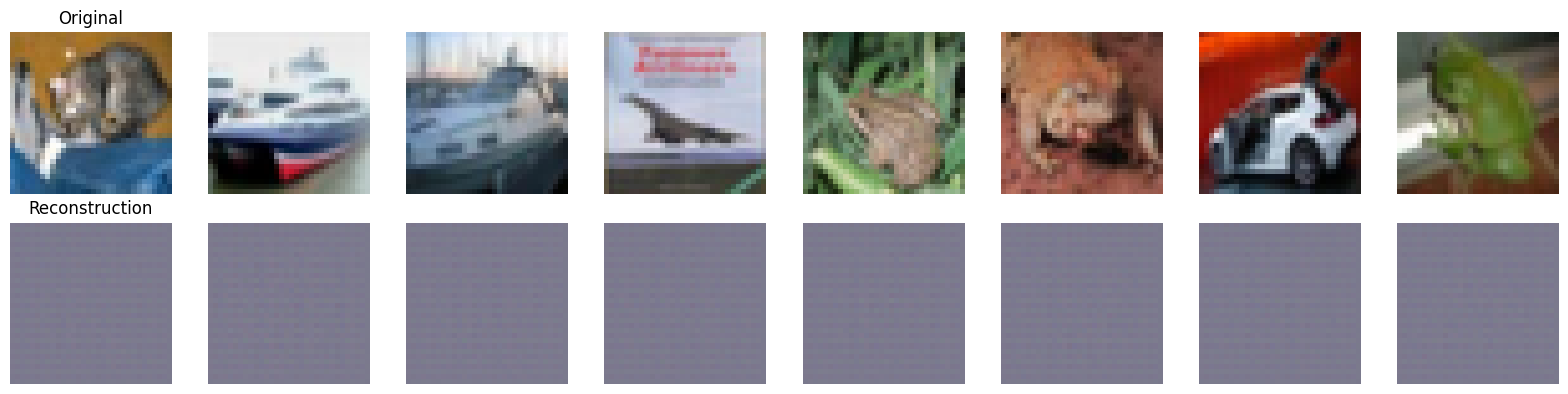

In [6]:
def visualize_reconstruction(model, data_loader, device, num_images=8):
    """Визуализирует оригиналы и их реконструкции моделью."""
    model.eval()  # Режим оценки
    with torch.no_grad():  # Отключаем градиенты
        # Один батч данных
        data_iter = iter(data_loader)
        images, _ = next(data_iter)
        images = images[:num_images].to(device)

        # Получаем реконструкции
        reconstructions, _, _ = model(images)

        # Инвертируем нормализацию: из [-1, 1] обратно в [0, 1]
        images = (images.cpu().numpy() + 1) / 2
        reconstructions = (reconstructions.cpu().numpy() + 1) / 2
        
        images = np.transpose(images, (0, 2, 3, 1))
        reconstructions = np.transpose(reconstructions, (0, 2, 3, 1))

        # Рисуем
        fig, axes = plt.subplots(2, num_images, figsize=(num_images * 2, 4))
        for i in range(num_images):
            # Оригинал сверху
            axes[0, i].imshow(np.clip(images[i], 0, 1))
            axes[0, i].axis('off')
            if i == 0:
                axes[0, i].set_title('Original')

            # Реконструкция снизу
            axes[1, i].imshow(np.clip(reconstructions[i], 0, 1))
            axes[1, i].axis('off')
            if i == 0:
                axes[1, i].set_title('Reconstruction')

        plt.tight_layout()
        plt.show()
    model.train()

# Посмотрим на то, что выдает до обучения
print("Reconstructions BEFORE training:")
visualize_reconstruction(model, test_loader, device)

# Обучение

Starting Training...


Epoch 1/50: 100%|██████████| 391/391 [00:32<00:00, 12.11it/s, Loss=248.0669, Recon=215.3874, KL=32.6795]


====> Epoch: 1 Average loss: 387.2455 (Recon: 356.4009, KL: 30.8446)


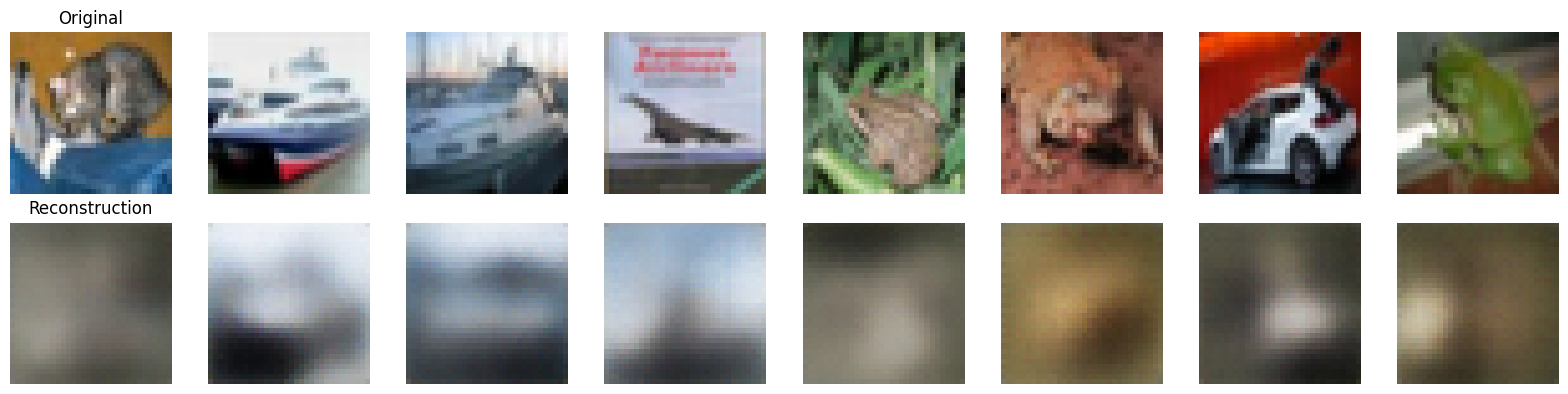

Epoch 2/50: 100%|██████████| 391/391 [00:26<00:00, 14.61it/s, Loss=249.3797, Recon=209.7469, KL=39.6328]


====> Epoch: 2 Average loss: 251.2691 (Recon: 214.1401, KL: 37.1290)


Epoch 3/50: 100%|██████████| 391/391 [00:31<00:00, 12.42it/s, Loss=241.4899, Recon=197.2948, KL=44.1951]


====> Epoch: 3 Average loss: 229.5815 (Recon: 188.5909, KL: 40.9906)


Epoch 4/50: 100%|██████████| 391/391 [00:37<00:00, 10.36it/s, Loss=216.9574, Recon=170.8250, KL=46.1323]


====> Epoch: 4 Average loss: 218.2874 (Recon: 174.4110, KL: 43.8764)


Epoch 5/50: 100%|██████████| 391/391 [01:24<00:00,  4.63it/s, Loss=212.5608, Recon=163.9344, KL=48.6264]


====> Epoch: 5 Average loss: 212.2916 (Recon: 166.6030, KL: 45.6886)


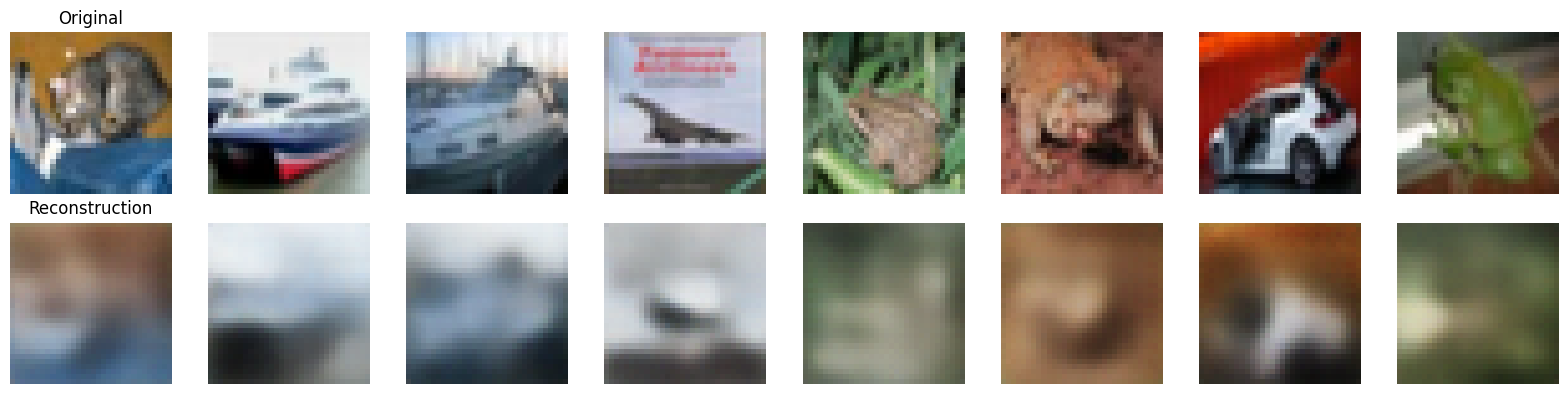

Epoch 6/50: 100%|██████████| 391/391 [00:35<00:00, 10.91it/s, Loss=206.0223, Recon=159.1669, KL=46.8554]


====> Epoch: 6 Average loss: 208.1517 (Recon: 161.4497, KL: 46.7019)


Epoch 7/50: 100%|██████████| 391/391 [01:10<00:00,  5.56it/s, Loss=213.5685, Recon=164.1805, KL=49.3880]


====> Epoch: 7 Average loss: 205.1577 (Recon: 157.2439, KL: 47.9137)


Epoch 8/50: 100%|██████████| 391/391 [01:11<00:00,  5.49it/s, Loss=201.7384, Recon=153.0934, KL=48.6449]


====> Epoch: 8 Average loss: 202.3333 (Recon: 153.0630, KL: 49.2703)


Epoch 9/50: 100%|██████████| 391/391 [01:10<00:00,  5.54it/s, Loss=199.5901, Recon=149.1400, KL=50.4502]


====> Epoch: 9 Average loss: 200.0935 (Recon: 149.8699, KL: 50.2236)


Epoch 10/50: 100%|██████████| 391/391 [01:11<00:00,  5.47it/s, Loss=200.9661, Recon=150.2695, KL=50.6967]


====> Epoch: 10 Average loss: 198.6952 (Recon: 147.8517, KL: 50.8435)


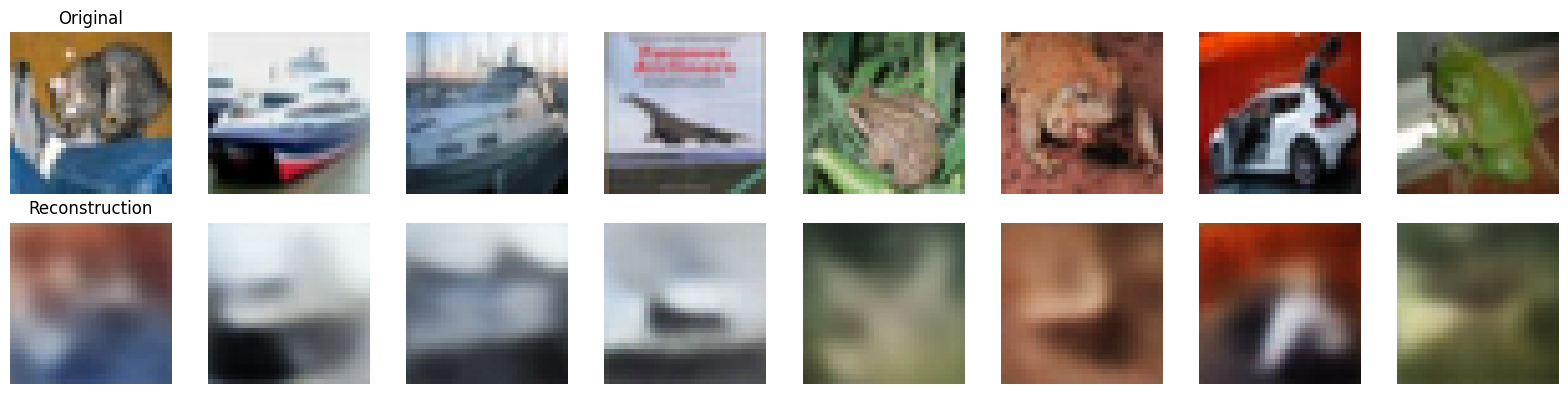

Epoch 11/50: 100%|██████████| 391/391 [01:11<00:00,  5.48it/s, Loss=191.1027, Recon=140.5780, KL=50.5247]


====> Epoch: 11 Average loss: 197.5702 (Recon: 146.1702, KL: 51.4000)


Epoch 12/50: 100%|██████████| 391/391 [01:10<00:00,  5.52it/s, Loss=207.7370, Recon=155.6430, KL=52.0939]


====> Epoch: 12 Average loss: 196.5289 (Recon: 144.6621, KL: 51.8668)


Epoch 13/50: 100%|██████████| 391/391 [01:10<00:00,  5.54it/s, Loss=201.2492, Recon=149.2682, KL=51.9810]


====> Epoch: 13 Average loss: 195.1915 (Recon: 142.6318, KL: 52.5597)


Epoch 14/50: 100%|██████████| 391/391 [01:10<00:00,  5.55it/s, Loss=181.1700, Recon=129.6003, KL=51.5697]


====> Epoch: 14 Average loss: 194.3089 (Recon: 141.2133, KL: 53.0955)


Epoch 15/50: 100%|██████████| 391/391 [00:48<00:00,  8.02it/s, Loss=193.9967, Recon=140.5287, KL=53.4680]


====> Epoch: 15 Average loss: 193.2547 (Recon: 139.6369, KL: 53.6178)


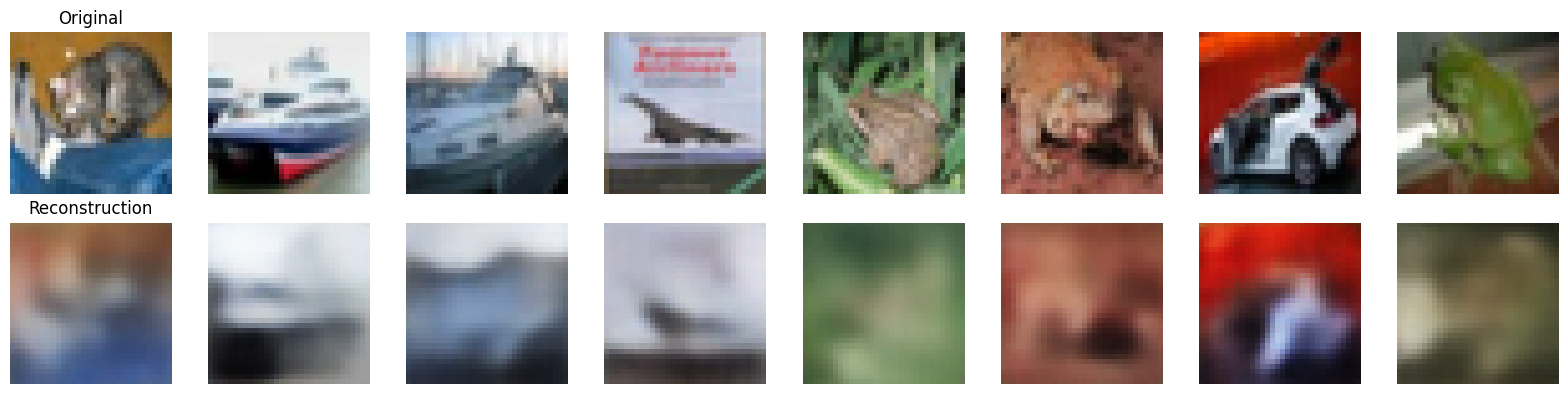

Epoch 16/50: 100%|██████████| 391/391 [00:28<00:00, 13.80it/s, Loss=184.2263, Recon=132.4440, KL=51.7823]


====> Epoch: 16 Average loss: 192.7139 (Recon: 138.7354, KL: 53.9785)


Epoch 17/50: 100%|██████████| 391/391 [00:27<00:00, 14.20it/s, Loss=192.5304, Recon=138.0839, KL=54.4464]


====> Epoch: 17 Average loss: 192.0710 (Recon: 137.7679, KL: 54.3031)


Epoch 18/50: 100%|██████████| 391/391 [00:27<00:00, 14.47it/s, Loss=212.1842, Recon=154.1836, KL=58.0006]


====> Epoch: 18 Average loss: 191.4061 (Recon: 136.7957, KL: 54.6104)


Epoch 19/50: 100%|██████████| 391/391 [00:26<00:00, 14.48it/s, Loss=195.1090, Recon=139.4492, KL=55.6599]


====> Epoch: 19 Average loss: 190.9872 (Recon: 136.0060, KL: 54.9812)


Epoch 20/50: 100%|██████████| 391/391 [00:26<00:00, 14.66it/s, Loss=194.0094, Recon=139.0548, KL=54.9546]


====> Epoch: 20 Average loss: 190.2405 (Recon: 135.0100, KL: 55.2305)


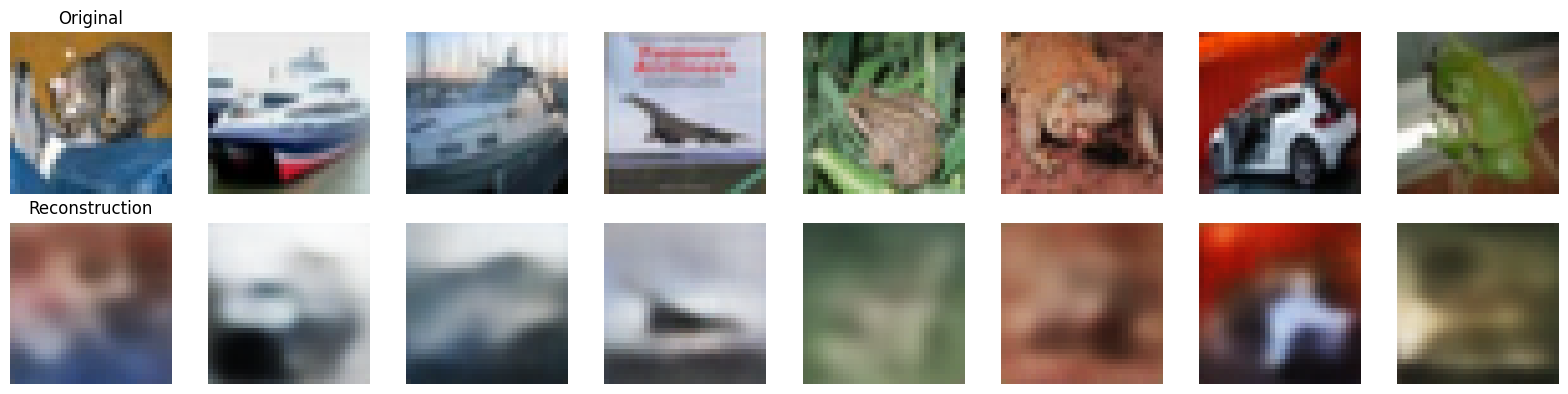

Epoch 21/50: 100%|██████████| 391/391 [00:27<00:00, 14.45it/s, Loss=198.2926, Recon=140.4520, KL=57.8407]


====> Epoch: 21 Average loss: 189.7647 (Recon: 134.2010, KL: 55.5638)


Epoch 22/50: 100%|██████████| 391/391 [00:26<00:00, 14.85it/s, Loss=196.9726, Recon=139.5161, KL=57.4565]


====> Epoch: 22 Average loss: 189.3145 (Recon: 133.3920, KL: 55.9225)


Epoch 23/50: 100%|██████████| 391/391 [00:27<00:00, 14.20it/s, Loss=189.1329, Recon=133.9541, KL=55.1789]


====> Epoch: 23 Average loss: 188.8887 (Recon: 132.7702, KL: 56.1185)


Epoch 24/50: 100%|██████████| 391/391 [00:27<00:00, 14.41it/s, Loss=184.7868, Recon=127.2776, KL=57.5092]


====> Epoch: 24 Average loss: 188.4588 (Recon: 131.9951, KL: 56.4637)


Epoch 25/50: 100%|██████████| 391/391 [00:26<00:00, 14.65it/s, Loss=183.7719, Recon=128.5609, KL=55.2110]


====> Epoch: 25 Average loss: 188.1416 (Recon: 131.3825, KL: 56.7591)


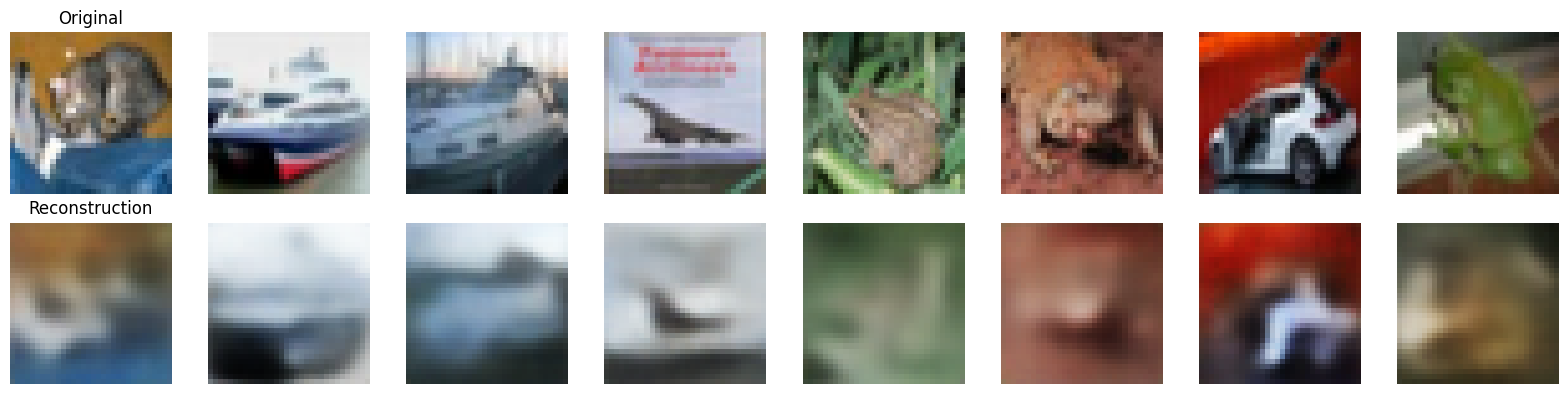

Epoch 26/50: 100%|██████████| 391/391 [00:28<00:00, 13.94it/s, Loss=191.2842, Recon=133.4725, KL=57.8117]


====> Epoch: 26 Average loss: 187.7733 (Recon: 130.8077, KL: 56.9656)


Epoch 27/50: 100%|██████████| 391/391 [00:26<00:00, 15.03it/s, Loss=184.5014, Recon=126.9224, KL=57.5790]


====> Epoch: 27 Average loss: 187.3382 (Recon: 130.1387, KL: 57.1995)


Epoch 28/50: 100%|██████████| 391/391 [00:27<00:00, 14.45it/s, Loss=187.2066, Recon=128.9475, KL=58.2591]


====> Epoch: 28 Average loss: 187.2225 (Recon: 129.8801, KL: 57.3424)


Epoch 29/50: 100%|██████████| 391/391 [00:27<00:00, 14.26it/s, Loss=198.8734, Recon=138.7007, KL=60.1727]


====> Epoch: 29 Average loss: 187.0256 (Recon: 129.5384, KL: 57.4872)


Epoch 30/50: 100%|██████████| 391/391 [00:27<00:00, 14.10it/s, Loss=186.3577, Recon=127.2740, KL=59.0837]


====> Epoch: 30 Average loss: 186.8261 (Recon: 129.2156, KL: 57.6105)


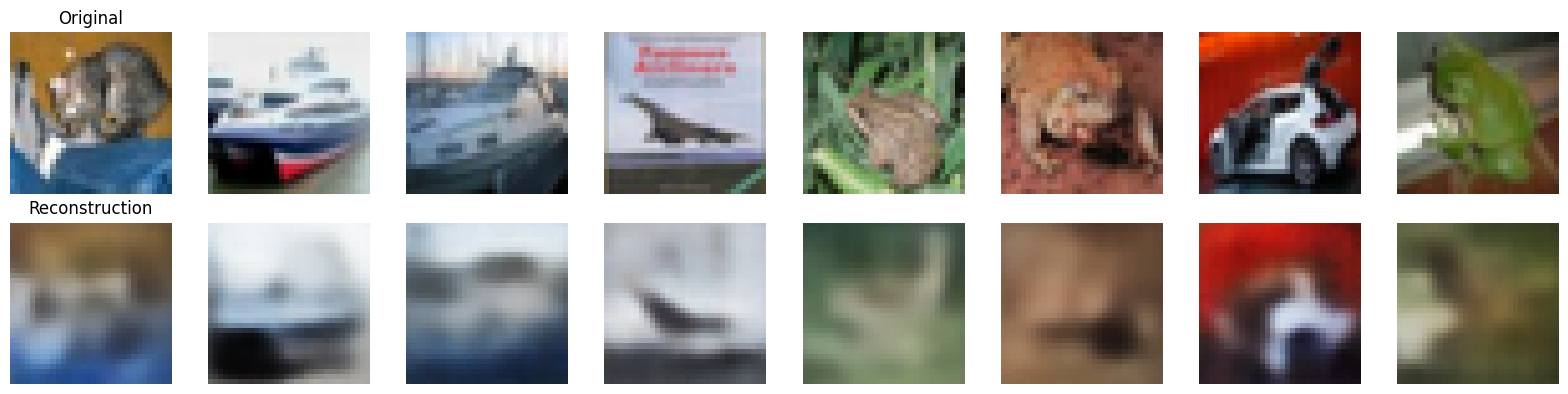

Epoch 31/50: 100%|██████████| 391/391 [00:27<00:00, 13.97it/s, Loss=182.7521, Recon=123.9310, KL=58.8211]


====> Epoch: 31 Average loss: 186.5522 (Recon: 128.8291, KL: 57.7232)


Epoch 32/50: 100%|██████████| 391/391 [00:27<00:00, 14.45it/s, Loss=202.0413, Recon=142.7939, KL=59.2474]


====> Epoch: 32 Average loss: 186.2154 (Recon: 128.4719, KL: 57.7435)


Epoch 33/50: 100%|██████████| 391/391 [00:27<00:00, 14.31it/s, Loss=192.1895, Recon=133.9050, KL=58.2846]


====> Epoch: 33 Average loss: 186.2197 (Recon: 128.3413, KL: 57.8784)


Epoch 34/50: 100%|██████████| 391/391 [00:28<00:00, 13.96it/s, Loss=172.0483, Recon=116.9695, KL=55.0788]


====> Epoch: 34 Average loss: 185.9541 (Recon: 127.9988, KL: 57.9553)


Epoch 35/50: 100%|██████████| 391/391 [00:26<00:00, 14.80it/s, Loss=175.6785, Recon=120.8486, KL=54.8299]


====> Epoch: 35 Average loss: 185.7303 (Recon: 127.6900, KL: 58.0403)


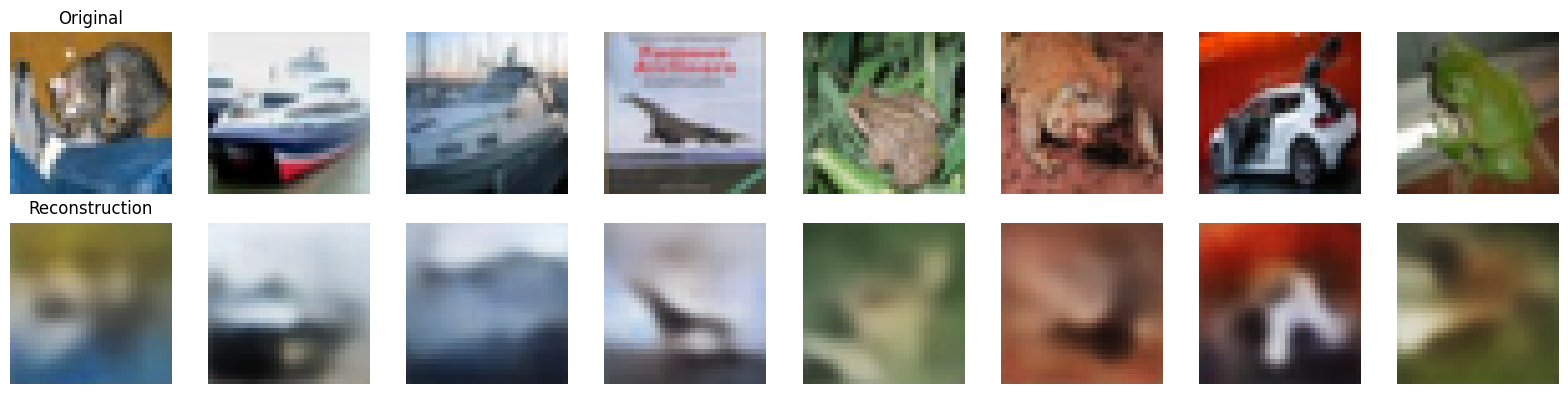

Epoch 36/50: 100%|██████████| 391/391 [00:28<00:00, 13.85it/s, Loss=189.0470, Recon=131.1504, KL=57.8966]


====> Epoch: 36 Average loss: 185.7871 (Recon: 127.6825, KL: 58.1045)


Epoch 37/50: 100%|██████████| 391/391 [00:27<00:00, 14.18it/s, Loss=180.6602, Recon=125.3027, KL=55.3576]


====> Epoch: 37 Average loss: 185.6378 (Recon: 127.4399, KL: 58.1979)


Epoch 38/50: 100%|██████████| 391/391 [00:27<00:00, 14.36it/s, Loss=179.4770, Recon=122.9705, KL=56.5066]


====> Epoch: 38 Average loss: 185.3590 (Recon: 127.0038, KL: 58.3551)


Epoch 39/50: 100%|██████████| 391/391 [00:27<00:00, 14.13it/s, Loss=193.7525, Recon=133.5094, KL=60.2431]


====> Epoch: 39 Average loss: 185.1209 (Recon: 126.6587, KL: 58.4622)


Epoch 40/50: 100%|██████████| 391/391 [00:27<00:00, 14.21it/s, Loss=183.3500, Recon=124.9065, KL=58.4434]


====> Epoch: 40 Average loss: 184.9397 (Recon: 126.4599, KL: 58.4798)


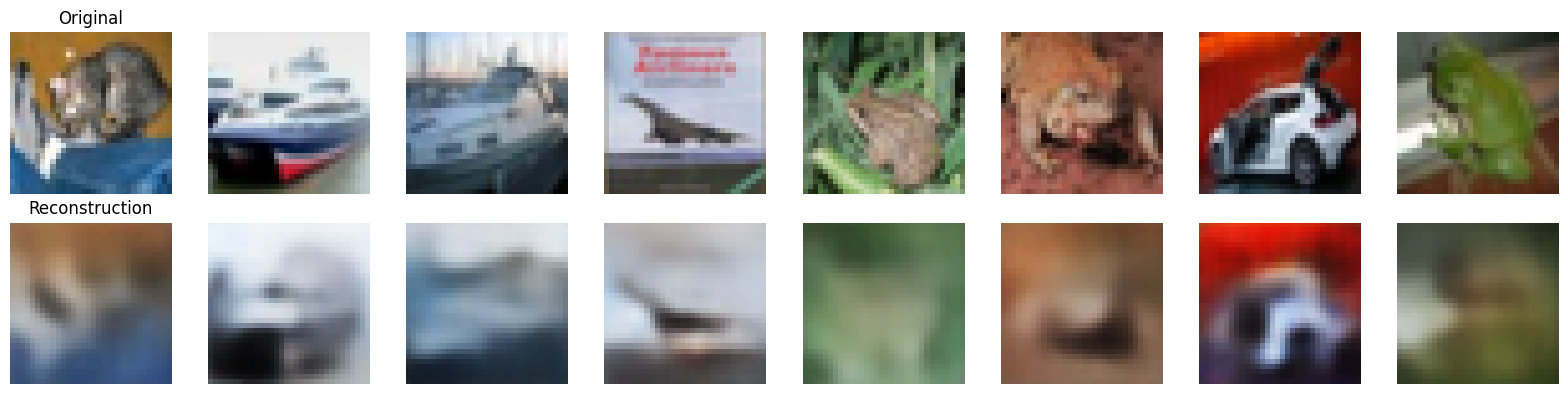

Epoch 41/50: 100%|██████████| 391/391 [00:28<00:00, 13.58it/s, Loss=183.9895, Recon=126.1951, KL=57.7944]


====> Epoch: 41 Average loss: 184.8904 (Recon: 126.2624, KL: 58.6280)


Epoch 42/50: 100%|██████████| 391/391 [00:28<00:00, 13.94it/s, Loss=183.4427, Recon=124.5671, KL=58.8756]


====> Epoch: 42 Average loss: 184.7255 (Recon: 125.9304, KL: 58.7951)


Epoch 43/50: 100%|██████████| 391/391 [00:27<00:00, 14.30it/s, Loss=181.6361, Recon=122.1898, KL=59.4463]


====> Epoch: 43 Average loss: 184.5648 (Recon: 125.6787, KL: 58.8861)


Epoch 44/50: 100%|██████████| 391/391 [00:28<00:00, 13.62it/s, Loss=184.6803, Recon=125.1277, KL=59.5526]


====> Epoch: 44 Average loss: 184.3494 (Recon: 125.3920, KL: 58.9574)


Epoch 45/50: 100%|██████████| 391/391 [00:28<00:00, 13.84it/s, Loss=193.6713, Recon=135.9084, KL=57.7629]


====> Epoch: 45 Average loss: 184.2832 (Recon: 125.2660, KL: 59.0173)


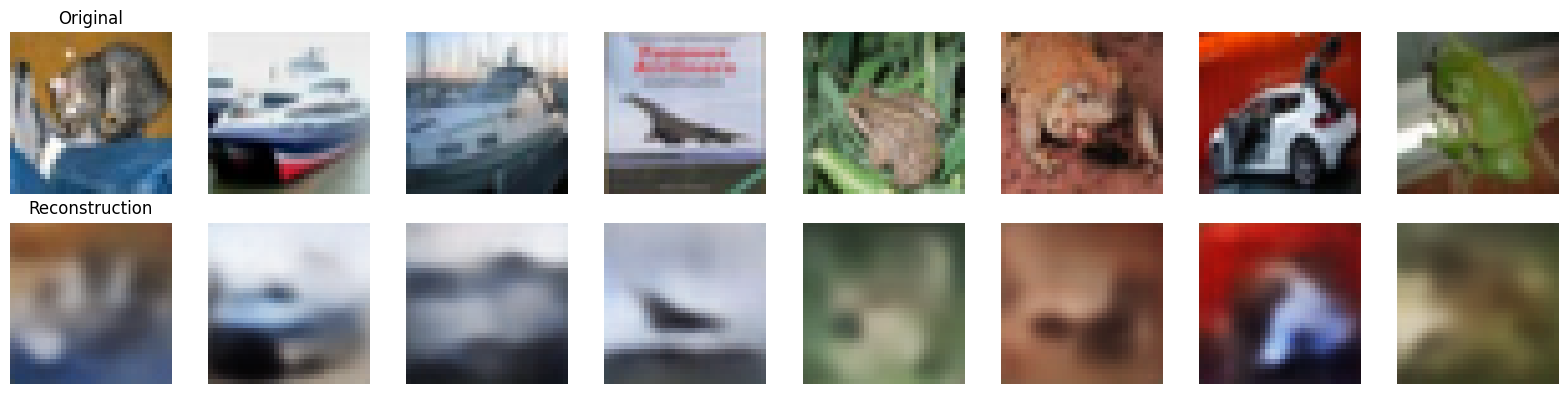

Epoch 46/50: 100%|██████████| 391/391 [00:27<00:00, 14.05it/s, Loss=179.5349, Recon=121.5643, KL=57.9706]


====> Epoch: 46 Average loss: 184.0152 (Recon: 124.8890, KL: 59.1261)


Epoch 47/50: 100%|██████████| 391/391 [01:11<00:00,  5.43it/s, Loss=179.5808, Recon=120.6560, KL=58.9248]


====> Epoch: 47 Average loss: 184.0522 (Recon: 124.8332, KL: 59.2190)


Epoch 48/50: 100%|██████████| 391/391 [01:17<00:00,  5.07it/s, Loss=180.7469, Recon=122.9317, KL=57.8152]


====> Epoch: 48 Average loss: 183.8669 (Recon: 124.5522, KL: 59.3147)


Epoch 49/50: 100%|██████████| 391/391 [00:39<00:00,  9.83it/s, Loss=188.7191, Recon=127.3677, KL=61.3514]


====> Epoch: 49 Average loss: 183.6904 (Recon: 124.2969, KL: 59.3936)


Epoch 50/50: 100%|██████████| 391/391 [01:18<00:00,  5.01it/s, Loss=187.3446, Recon=128.8073, KL=58.5373]


====> Epoch: 50 Average loss: 183.5484 (Recon: 124.0335, KL: 59.5148)


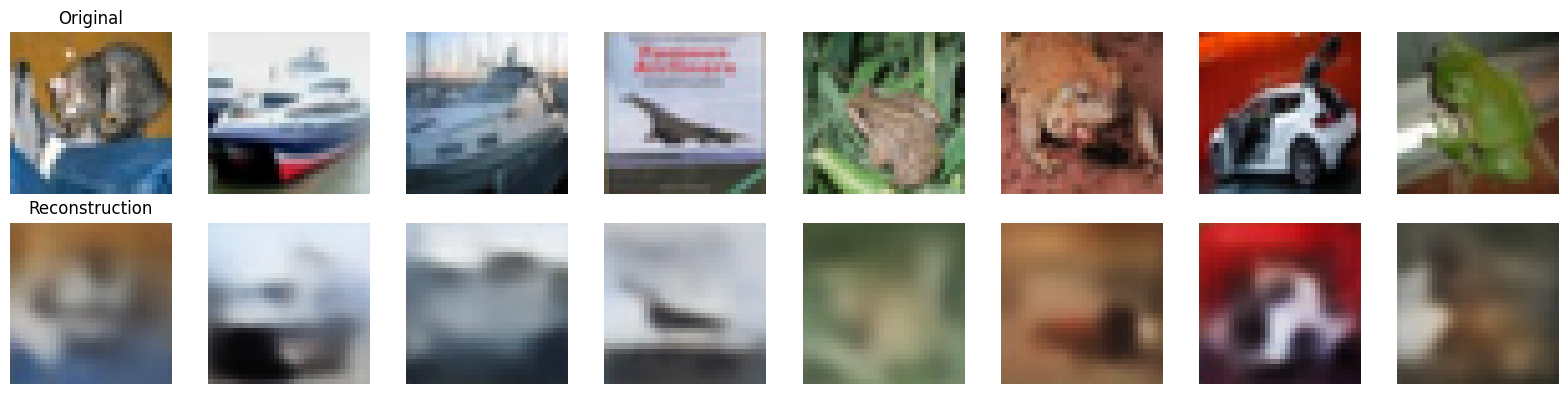

Training Finished!


In [7]:
# История ошибок
train_losses = []
recon_losses = []
kl_losses = []

print("Starting Training...")
for epoch in range(1, num_epochs + 1):
    model.train()
    total_loss_epoch = 0
    total_recon_loss_epoch = 0
    total_kl_loss_epoch = 0

    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch}/{num_epochs}')

    for batch_idx, (data, _) in enumerate(progress_bar):
        data = data.to(device)

        # 1. Обнуляем градиенты
        optimizer.zero_grad()

        # 2. Forward pass
        recon_batch, mu, log_var = model(data)

        # 3. Вычисляем функцию потерь
        loss, recon_loss, kl_loss = vae_loss(recon_batch, data, mu, log_var)

        # 4. Backward pass - вычисляем градиенты
        loss.backward()

        # 5. Обновляем веса
        optimizer.step()

        # 6. Собираем статистику
        total_loss_epoch += loss.item()
        total_recon_loss_epoch += recon_loss.item()
        total_kl_loss_epoch += kl_loss.item()

        progress_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Recon': f'{recon_loss.item():.4f}',
            'KL': f'{kl_loss.item():.4f}'
        })

    # Средние потери за эпоху
    avg_loss = total_loss_epoch / len(train_loader)
    avg_recon = total_recon_loss_epoch / len(train_loader)
    avg_kl = total_kl_loss_epoch / len(train_loader)

    train_losses.append(avg_loss)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)

    print(f'====> Epoch: {epoch} Average loss: {avg_loss:.4f} (Recon: {avg_recon:.4f}, KL: {avg_kl:.4f})')

    # Каждые 5 эпох показываем реконструкции и сохраняем картинку
    if epoch % 5 == 0 or epoch == 1:
        visualize_reconstruction(model, test_loader, device)

        model.eval()
        with torch.no_grad():
            sample_z = torch.randn(64, latent_dim).to(device)
            sample_images = model.decode(sample_z)
            # Сохраняем в виде сетки
            save_image(sample_images, f'./vae_outputs/epoch_{epoch}.png', nrow=8, normalize=True)
        model.train()

    torch.save(model.state_dict(), f'./vae_weights/vae_epoch_{epoch}.pth')

print("Training Finished!")

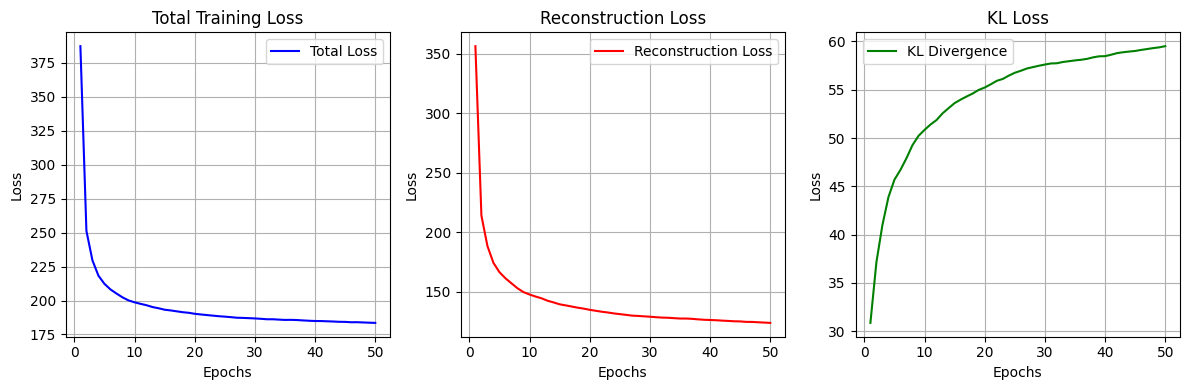

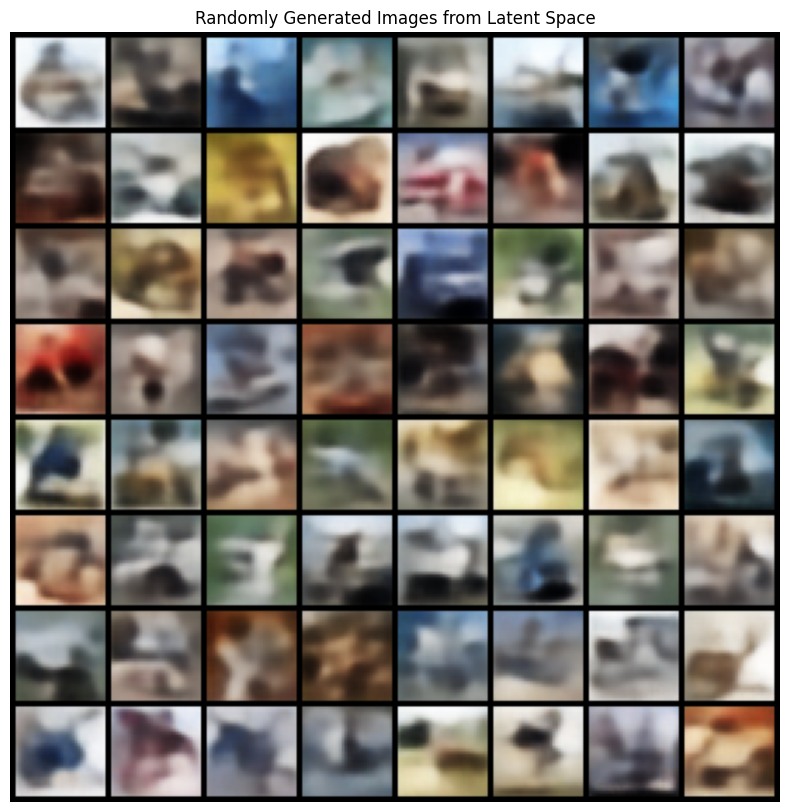

Final generated images saved to ./vae_outputs/final_generation.png


In [ ]:
# Функция для отрисовки графиков обучения
def plot_losses(train_losses, recon_losses, kl_losses):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_losses, 'b-', label='Total Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Total Training Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(epochs, recon_losses, 'r-', label='Reconstruction Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Reconstruction Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(epochs, kl_losses, 'g-', label='KL Divergence')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('KL Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Рисуем графики
plot_losses(train_losses, recon_losses, kl_losses)

model.eval()
with torch.no_grad():
    # Генерируем 64 новые картинки
    sample_z = torch.randn(64, latent_dim).to(device)
    generated_images = model.decode(sample_z)

    # Визуализируем их
    grid = make_grid(generated_images, nrow=8, normalize=True).cpu().numpy()
    grid = np.transpose(grid, (1, 2, 0))

    plt.figure(figsize=(10, 10))
    plt.imshow(np.clip(grid, 0, 1))
    plt.axis('off')
    plt.title('Randomly Generated Images from Latent Space')
    plt.show()

    # Сохраняем их
    save_image(generated_images, './vae_outputs/final_generation.png', nrow=8, normalize=True)
    print("Final generated images saved to ./vae_outputs/final_generation.png")

Получились +- похожие картинки, но все еще нузнаваемые образы. Чтобы не терять прогресс обучения, продолжаю обучение но немного с другими параметрами. Не стала перезапускать обучение, которое и так уже отработало. Скопировала уже существующую функцию, но добавила параметры, которые позволят не начинать обучение с нуля.

Найдены сохраненные веса: ./vae_weights/vae_epoch_50.pth
Продолжаем обучение с эпохи 51
Starting Training...


Epoch 51/100:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 51/100: 100%|██████████| 391/391 [00:47<00:00,  8.29it/s, Loss=192.0892, Recon=130.9926, KL=61.0965]


====> Epoch: 51 Average loss: 183.3936 (Recon: 123.8030, KL: 59.5906)


Epoch 52/100: 100%|██████████| 391/391 [00:29<00:00, 13.05it/s, Loss=179.1127, Recon=121.0513, KL=58.0614]


...

====> Epoch: 53 Average loss: 183.2180 (Recon: 123.5227, KL: 59.6953)


Epoch 54/100: 100%|██████████| 391/391 [00:27<00:00, 14.02it/s, Loss=189.2444, Recon=130.6207, KL=58.6236]


====> Epoch: 54 Average loss: 183.1480 (Recon: 123.3334, KL: 59.8145)


Epoch 55/100: 100%|██████████| 391/391 [00:27<00:00, 14.00it/s, Loss=182.5756, Recon=122.0071, KL=60.5685]


====> Epoch: 55 Average loss: 183.0568 (Recon: 123.2226, KL: 59.8342)


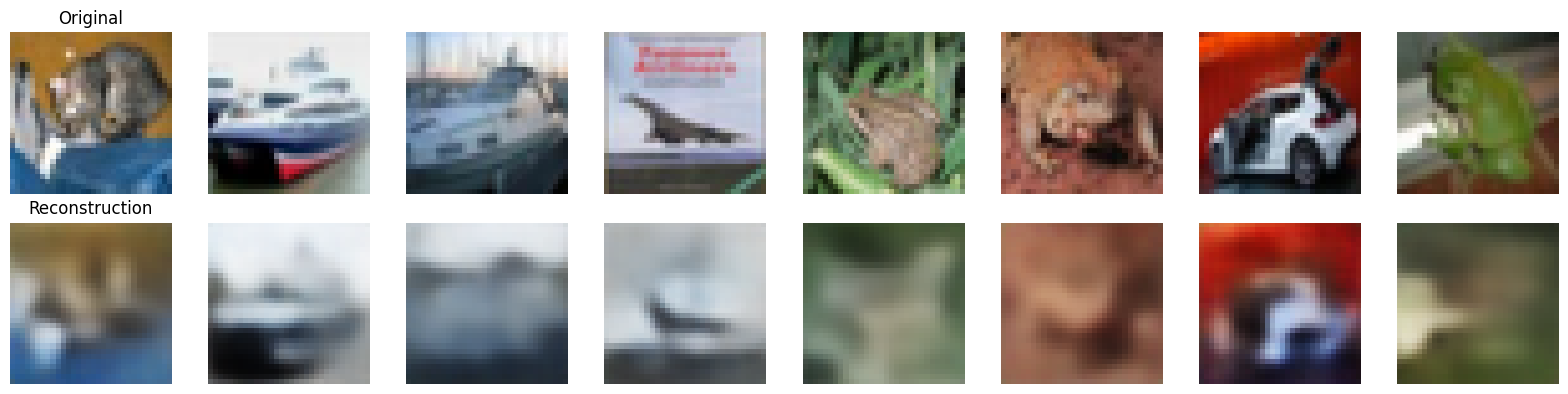

Epoch 56/100: 100%|██████████| 391/391 [01:24<00:00,  4.65it/s, Loss=177.4956, Recon=117.2102, KL=60.2854]


====> Epoch: 56 Average loss: 182.9500 (Recon: 123.0439, KL: 59.9061)


Epoch 57/100: 100%|██████████| 391/391 [01:16<00:00,  5.13it/s, Loss=186.9411, Recon=126.3107, KL=60.6305]


====> Epoch: 57 Average loss: 182.8655 (Recon: 122.9400, KL: 59.9256)


Epoch 58/100: 100%|██████████| 391/391 [01:28<00:00,  4.40it/s, Loss=178.8463, Recon=118.8046, KL=60.0418]


====> Epoch: 58 Average loss: 182.7450 (Recon: 122.6929, KL: 60.0521)


Epoch 59/100: 100%|██████████| 391/391 [01:23<00:00,  4.70it/s, Loss=183.6671, Recon=123.9202, KL=59.7469]


====> Epoch: 59 Average loss: 182.7001 (Recon: 122.6689, KL: 60.0313)


Epoch 60/100: 100%|██████████| 391/391 [01:16<00:00,  5.09it/s, Loss=186.0641, Recon=125.4179, KL=60.6462]


====> Epoch: 60 Average loss: 182.6489 (Recon: 122.5180, KL: 60.1309)


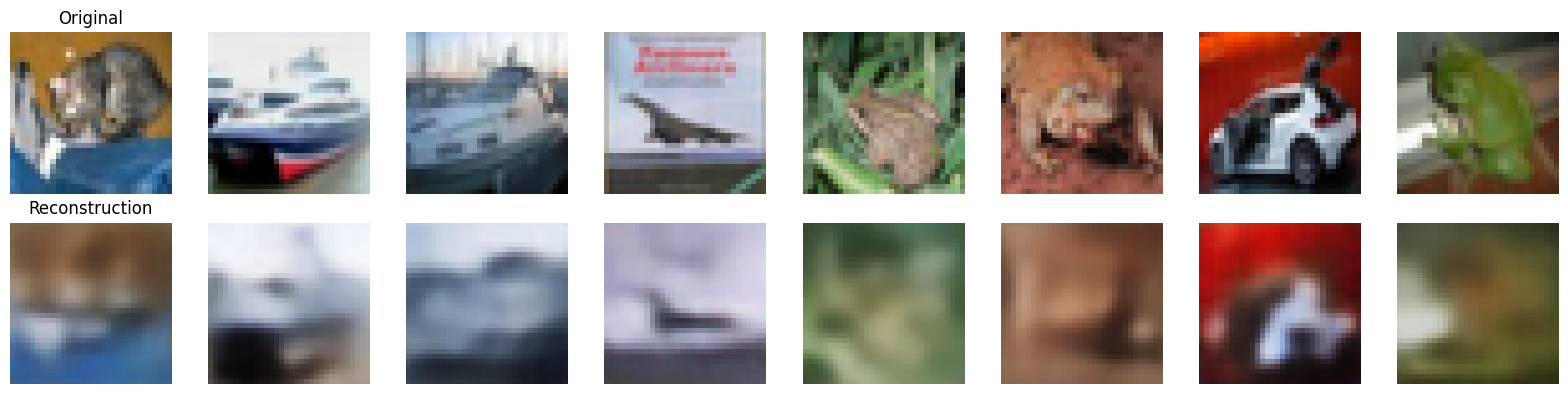

Epoch 61/100: 100%|██████████| 391/391 [01:12<00:00,  5.38it/s, Loss=190.4774, Recon=126.9582, KL=63.5192]


====> Epoch: 61 Average loss: 182.5243 (Recon: 122.3620, KL: 60.1622)


Epoch 62/100: 100%|██████████| 391/391 [01:13<00:00,  5.33it/s, Loss=179.3206, Recon=119.6170, KL=59.7035]


====> Epoch: 62 Average loss: 182.4714 (Recon: 122.2788, KL: 60.1926)


Epoch 63/100: 100%|██████████| 391/391 [01:16<00:00,  5.12it/s, Loss=175.9374, Recon=115.5765, KL=60.3609]


====> Epoch: 63 Average loss: 182.3989 (Recon: 122.1881, KL: 60.2108)


Epoch 64/100: 100%|██████████| 391/391 [01:25<00:00,  4.57it/s, Loss=204.2596, Recon=139.9655, KL=64.2940]


====> Epoch: 64 Average loss: 182.2931 (Recon: 122.0167, KL: 60.2764)


Epoch 65/100: 100%|██████████| 391/391 [01:15<00:00,  5.15it/s, Loss=188.6297, Recon=128.1217, KL=60.5080]


====> Epoch: 65 Average loss: 182.2554 (Recon: 121.9566, KL: 60.2987)


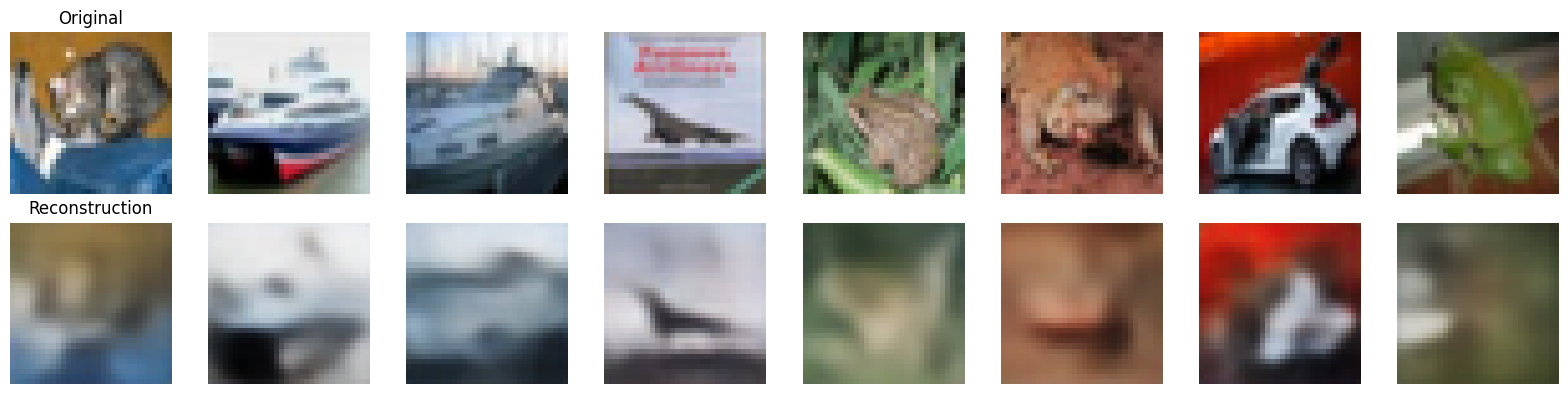

Epoch 66/100: 100%|██████████| 391/391 [01:19<00:00,  4.94it/s, Loss=192.3001, Recon=129.5609, KL=62.7392]


====> Epoch: 66 Average loss: 182.1070 (Recon: 121.7619, KL: 60.3450)


Epoch 67/100: 100%|██████████| 391/391 [01:13<00:00,  5.29it/s, Loss=175.3533, Recon=116.8283, KL=58.5250]


====> Epoch: 67 Average loss: 182.1351 (Recon: 121.7396, KL: 60.3955)


Epoch 68/100: 100%|██████████| 391/391 [01:14<00:00,  5.27it/s, Loss=180.7212, Recon=120.0427, KL=60.6784]


====> Epoch: 68 Average loss: 182.1412 (Recon: 121.7009, KL: 60.4403)


Epoch 69/100: 100%|██████████| 391/391 [01:17<00:00,  5.02it/s, Loss=176.5408, Recon=117.2044, KL=59.3364]


====> Epoch: 69 Average loss: 182.0471 (Recon: 121.5319, KL: 60.5152)


Epoch 70/100: 100%|██████████| 391/391 [01:23<00:00,  4.70it/s, Loss=180.0721, Recon=116.4709, KL=63.6012]


====> Epoch: 70 Average loss: 181.8385 (Recon: 121.3550, KL: 60.4835)


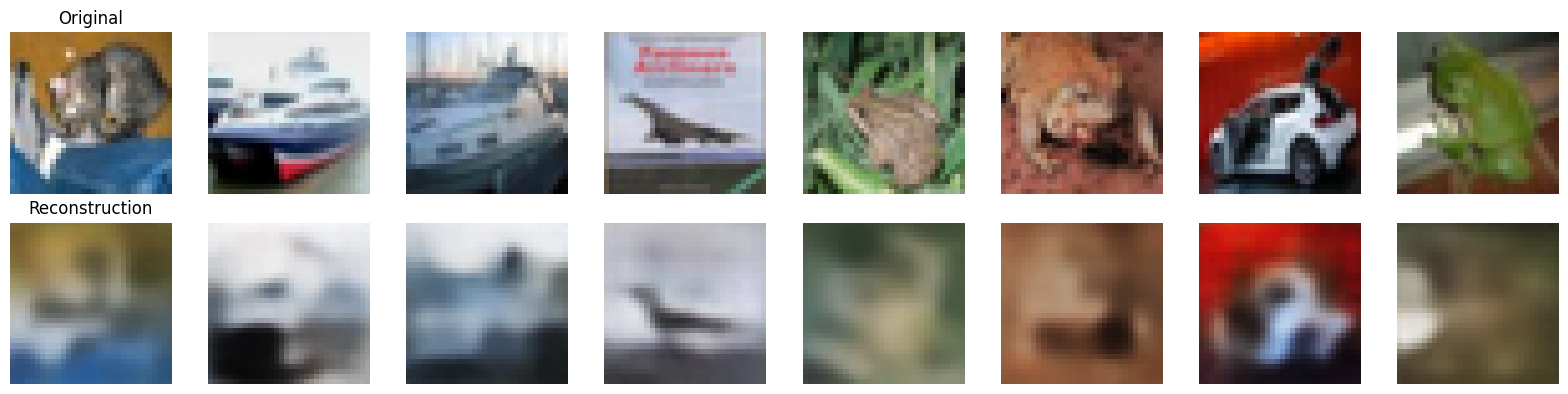

Epoch 71/100: 100%|██████████| 391/391 [01:16<00:00,  5.13it/s, Loss=182.6526, Recon=122.9397, KL=59.7128]


====> Epoch: 71 Average loss: 181.8439 (Recon: 121.3249, KL: 60.5190)


Epoch 72/100: 100%|██████████| 391/391 [01:25<00:00,  4.58it/s, Loss=193.8808, Recon=130.9379, KL=62.9429]


====> Epoch: 72 Average loss: 181.7712 (Recon: 121.2098, KL: 60.5614)


Epoch 73/100: 100%|██████████| 391/391 [01:17<00:00,  5.06it/s, Loss=175.7470, Recon=113.8360, KL=61.9110]


====> Epoch: 73 Average loss: 181.8351 (Recon: 121.2648, KL: 60.5702)


Epoch 74/100: 100%|██████████| 391/391 [01:00<00:00,  6.50it/s, Loss=172.8048, Recon=114.2936, KL=58.5112]


====> Epoch: 74 Average loss: 181.6412 (Recon: 121.0117, KL: 60.6296)


Epoch 75/100: 100%|██████████| 391/391 [01:24<00:00,  4.63it/s, Loss=186.0603, Recon=124.9752, KL=61.0852]


====> Epoch: 75 Average loss: 181.6219 (Recon: 121.0053, KL: 60.6166)


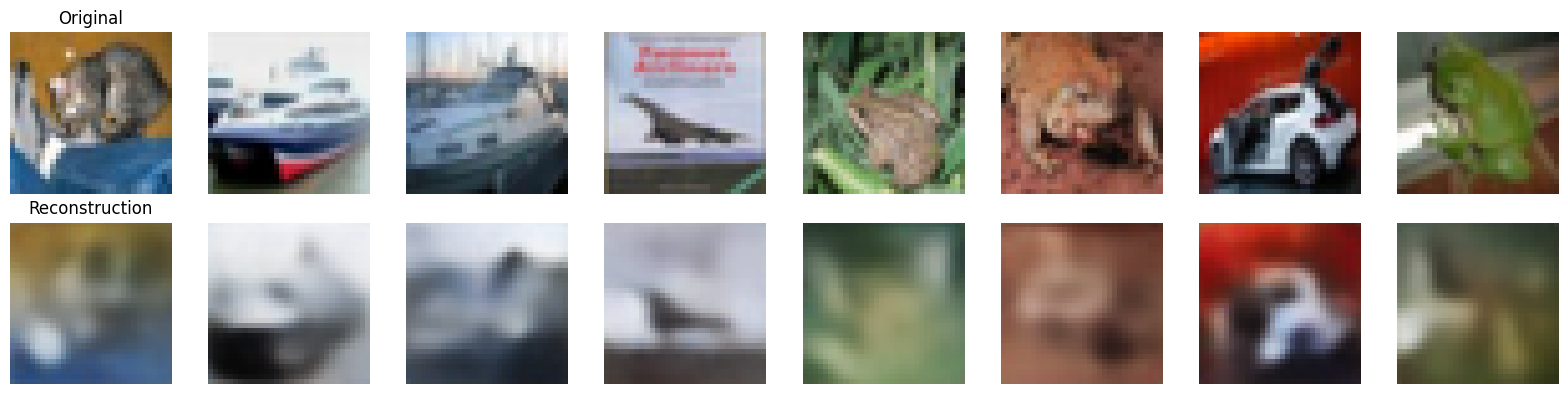

Epoch 76/100: 100%|██████████| 391/391 [01:21<00:00,  4.77it/s, Loss=190.0439, Recon=127.8099, KL=62.2340]


====> Epoch: 76 Average loss: 181.5671 (Recon: 120.8793, KL: 60.6878)


Epoch 77/100: 100%|██████████| 391/391 [01:27<00:00,  4.46it/s, Loss=186.4819, Recon=123.2315, KL=63.2504]


====> Epoch: 77 Average loss: 181.5131 (Recon: 120.8286, KL: 60.6845)


Epoch 78/100: 100%|██████████| 391/391 [01:21<00:00,  4.80it/s, Loss=191.0600, Recon=126.5898, KL=64.4702]


====> Epoch: 78 Average loss: 181.5021 (Recon: 120.8015, KL: 60.7006)


Epoch 79/100: 100%|██████████| 391/391 [01:08<00:00,  5.73it/s, Loss=177.9881, Recon=118.3728, KL=59.6153]


====> Epoch: 79 Average loss: 181.4453 (Recon: 120.7328, KL: 60.7125)


Epoch 80/100: 100%|██████████| 391/391 [01:18<00:00,  5.00it/s, Loss=189.1740, Recon=126.8777, KL=62.2964]


====> Epoch: 80 Average loss: 181.3644 (Recon: 120.5836, KL: 60.7808)


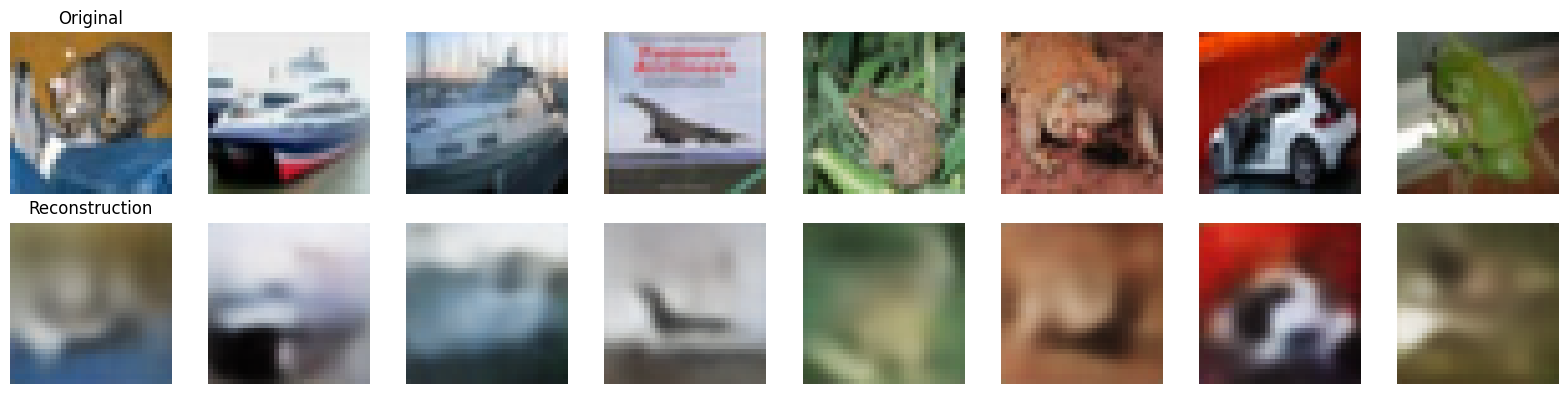

Epoch 81/100: 100%|██████████| 391/391 [01:22<00:00,  4.74it/s, Loss=183.7495, Recon=124.1345, KL=59.6150]


====> Epoch: 81 Average loss: 181.2952 (Recon: 120.4580, KL: 60.8372)


Epoch 82/100: 100%|██████████| 391/391 [01:20<00:00,  4.89it/s, Loss=190.1277, Recon=126.5193, KL=63.6084]


====> Epoch: 82 Average loss: 181.2374 (Recon: 120.4106, KL: 60.8268)


Epoch 83/100: 100%|██████████| 391/391 [01:20<00:00,  4.86it/s, Loss=190.3167, Recon=126.1329, KL=64.1838]


====> Epoch: 83 Average loss: 181.3199 (Recon: 120.4680, KL: 60.8518)


Epoch 84/100: 100%|██████████| 391/391 [01:16<00:00,  5.09it/s, Loss=183.2832, Recon=122.2607, KL=61.0224]


====> Epoch: 84 Average loss: 181.1404 (Recon: 120.2693, KL: 60.8711)


Epoch 85/100: 100%|██████████| 391/391 [00:44<00:00,  8.71it/s, Loss=176.9346, Recon=115.5032, KL=61.4314]


====> Epoch: 85 Average loss: 181.1310 (Recon: 120.2144, KL: 60.9166)


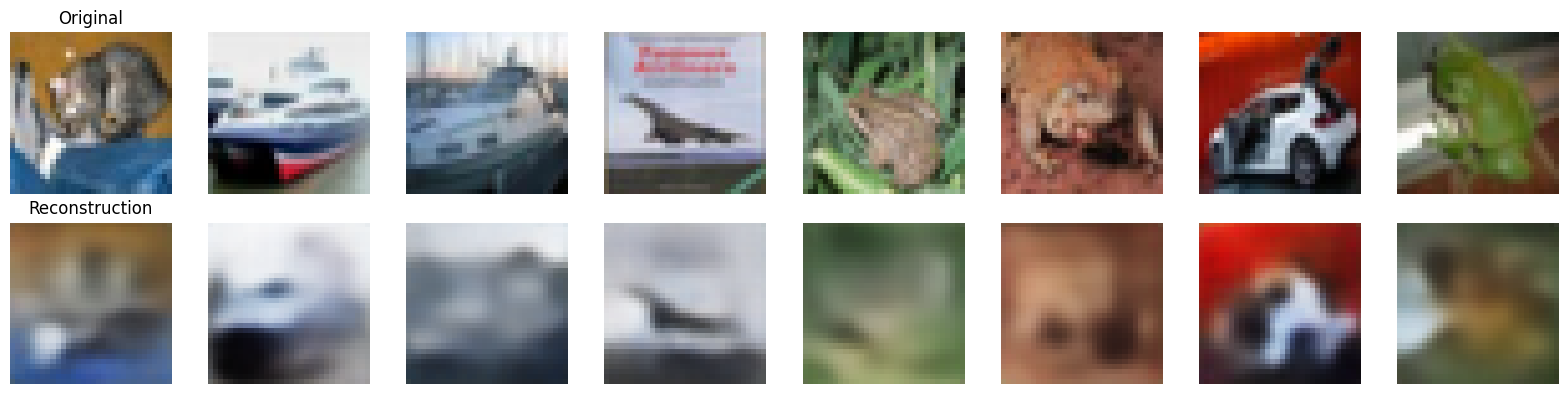

Epoch 86/100: 100%|██████████| 391/391 [01:22<00:00,  4.75it/s, Loss=183.7105, Recon=123.3794, KL=60.3311]


====> Epoch: 86 Average loss: 181.1790 (Recon: 120.2427, KL: 60.9363)


Epoch 87/100: 100%|██████████| 391/391 [01:08<00:00,  5.71it/s, Loss=182.4032, Recon=117.6173, KL=64.7859]


====> Epoch: 87 Average loss: 181.0876 (Recon: 120.1124, KL: 60.9752)


Epoch 88/100: 100%|██████████| 391/391 [01:17<00:00,  5.05it/s, Loss=177.2038, Recon=116.0245, KL=61.1793]


====> Epoch: 88 Average loss: 181.0507 (Recon: 120.0574, KL: 60.9933)


Epoch 89/100: 100%|██████████| 391/391 [01:16<00:00,  5.14it/s, Loss=188.3055, Recon=124.1467, KL=64.1588]


====> Epoch: 89 Average loss: 180.9560 (Recon: 119.9618, KL: 60.9942)


Epoch 90/100: 100%|██████████| 391/391 [01:23<00:00,  4.69it/s, Loss=170.7788, Recon=110.7135, KL=60.0654]


====> Epoch: 90 Average loss: 181.0645 (Recon: 120.0405, KL: 61.0240)


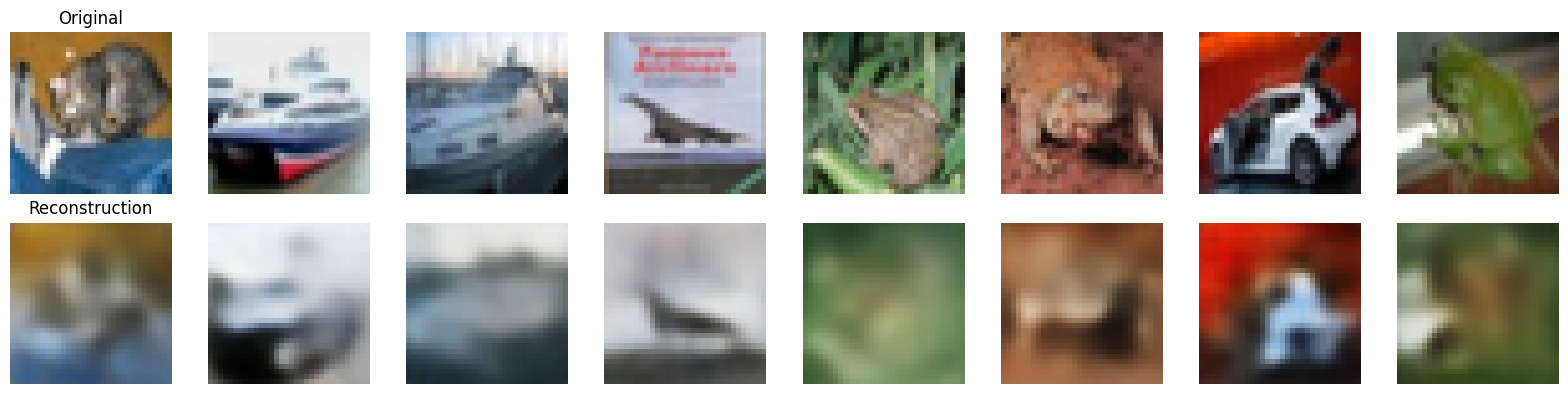

Epoch 91/100: 100%|██████████| 391/391 [01:19<00:00,  4.94it/s, Loss=180.1271, Recon=117.8890, KL=62.2381]


====> Epoch: 91 Average loss: 180.9295 (Recon: 119.8420, KL: 61.0875)


Epoch 92/100: 100%|██████████| 391/391 [01:21<00:00,  4.82it/s, Loss=189.4623, Recon=125.9858, KL=63.4766]


====> Epoch: 92 Average loss: 181.0279 (Recon: 119.8734, KL: 61.1546)


Epoch 93/100: 100%|██████████| 391/391 [01:19<00:00,  4.95it/s, Loss=171.5807, Recon=110.1385, KL=61.4422]


====> Epoch: 93 Average loss: 180.7769 (Recon: 119.6030, KL: 61.1739)


Epoch 94/100: 100%|██████████| 391/391 [01:18<00:00,  5.01it/s, Loss=180.9459, Recon=118.4498, KL=62.4961]


====> Epoch: 94 Average loss: 180.8116 (Recon: 119.6780, KL: 61.1336)


Epoch 95/100: 100%|██████████| 391/391 [01:17<00:00,  5.01it/s, Loss=189.0387, Recon=124.2184, KL=64.8203]


====> Epoch: 95 Average loss: 180.8338 (Recon: 119.6310, KL: 61.2029)


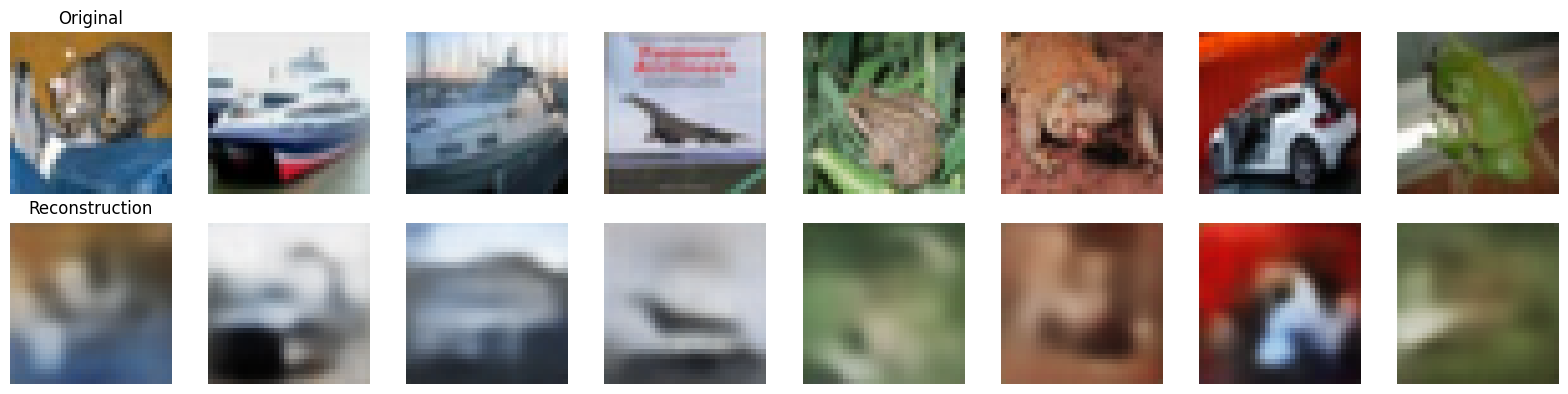

Epoch 96/100: 100%|██████████| 391/391 [01:17<00:00,  5.04it/s, Loss=191.3023, Recon=129.1705, KL=62.1318]


====> Epoch: 96 Average loss: 180.6546 (Recon: 119.5234, KL: 61.1312)


Epoch 97/100: 100%|██████████| 391/391 [01:11<00:00,  5.47it/s, Loss=180.6193, Recon=121.5036, KL=59.1157]


====> Epoch: 97 Average loss: 180.7878 (Recon: 119.5676, KL: 61.2201)


Epoch 98/100: 100%|██████████| 391/391 [01:08<00:00,  5.72it/s, Loss=172.7621, Recon=111.5501, KL=61.2121]


====> Epoch: 98 Average loss: 180.7040 (Recon: 119.4360, KL: 61.2680)


Epoch 99/100: 100%|██████████| 391/391 [01:16<00:00,  5.14it/s, Loss=177.2675, Recon=117.3111, KL=59.9564]


====> Epoch: 99 Average loss: 180.6336 (Recon: 119.3963, KL: 61.2373)


Epoch 100/100: 100%|██████████| 391/391 [01:18<00:00,  5.00it/s, Loss=183.7711, Recon=120.4797, KL=63.2914]


====> Epoch: 100 Average loss: 180.6561 (Recon: 119.2897, KL: 61.3664)


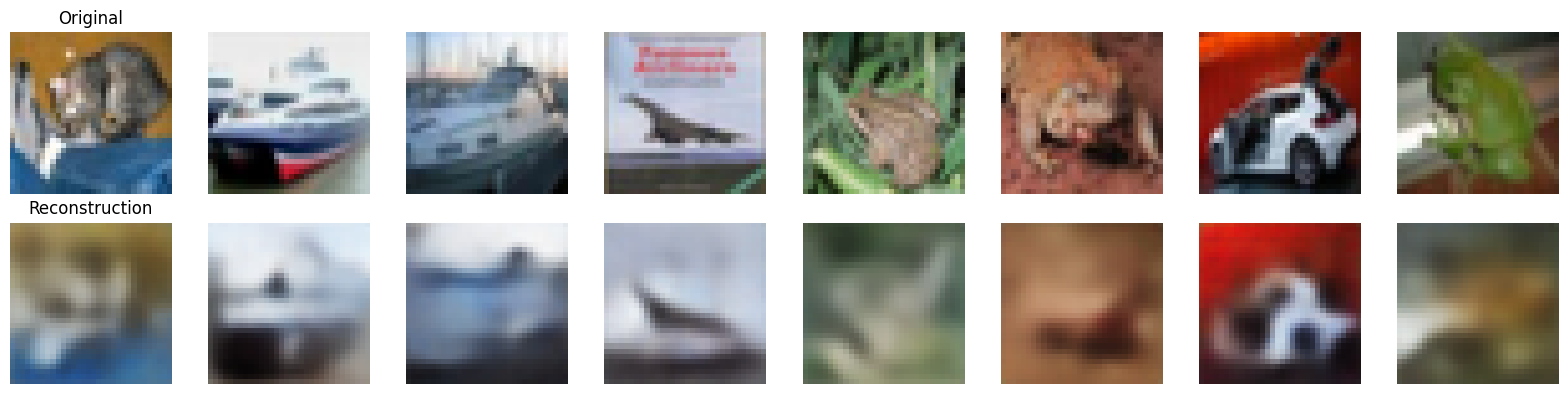

Training Finished!


In [10]:
start_epoch = 1  # По умолчанию начинаем с 1-й эпохи

# Проверяем, есть ли сохраненные веса
checkpoint_path = './vae_weights/vae_epoch_50.pth'  # Путь к последней сохраненной модели

if os.path.exists(checkpoint_path):
    print(f"Найдены сохраненные веса: {checkpoint_path}")
    # Загружаем веса в модель
    model.load_state_dict(torch.load(checkpoint_path))
    start_epoch = 51 
    print(f"Продолжаем обучение с эпохи {start_epoch}")
else:
    print("Сохраненных весов не найдено. Начинаем обучение с нуля.")
# ------------------------------------------------

num_epochs = 100

# История ошибок
train_losses = []
recon_losses = []
kl_losses = []

print("Starting Training...")
for epoch in range(start_epoch, num_epochs + 1):
    model.train()
    total_loss_epoch = 0
    total_recon_loss_epoch = 0
    total_kl_loss_epoch = 0

    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch}/{num_epochs}')

    for batch_idx, (data, _) in enumerate(progress_bar):
        data = data.to(device)

        # 1. Обнуляем градиенты
        optimizer.zero_grad()

        # 2. Forward pass
        recon_batch, mu, log_var = model(data)

        # 3. Вычисляем функцию потерь
        loss, recon_loss, kl_loss = vae_loss(recon_batch, data, mu, log_var)

        # 4. Backward pass - вычисляем градиенты
        loss.backward()

        # 5. Обновляем веса
        optimizer.step()

        # 6. Собираем статистику
        total_loss_epoch += loss.item()
        total_recon_loss_epoch += recon_loss.item()
        total_kl_loss_epoch += kl_loss.item()

        progress_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Recon': f'{recon_loss.item():.4f}',
            'KL': f'{kl_loss.item():.4f}'
        })

    # Средние потери за эпоху
    avg_loss = total_loss_epoch / len(train_loader)
    avg_recon = total_recon_loss_epoch / len(train_loader)
    avg_kl = total_kl_loss_epoch / len(train_loader)

    train_losses.append(avg_loss)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)

    print(f'====> Epoch: {epoch} Average loss: {avg_loss:.4f} (Recon: {avg_recon:.4f}, KL: {avg_kl:.4f})')

    # Каждые 5 эпох показываем реконструкции и сохраняем картинку
    if epoch % 5 == 0 or epoch == 1:
        visualize_reconstruction(model, test_loader, device)

        model.eval()
        with torch.no_grad():
            sample_z = torch.randn(64, latent_dim).to(device)
            sample_images = model.decode(sample_z)
            # Сохраняем в виде сетки
            save_image(sample_images, f'./vae_outputs/epoch_{epoch}.png', nrow=8, normalize=True)
        model.train()

    torch.save(model.state_dict(), f'./vae_weights/vae_epoch_{epoch}.pth')

print("Training Finished!")



In [11]:
def plot_training_history(train_losses=None, recon_losses=None, kl_losses=None, 
                          start_epoch=1, history_file=None, save_path=None):
    """
    Универсальная функция для отрисовки графиков обучения VAE
    
    Параметры:
    - train_losses: список общих потерь
    - recon_losses: список потерь реконструкции
    - kl_losses: список KL-дивергенций
    - start_epoch: номер первой эпохи (для случая продолжения обучения)
    - history_file: путь к файлу с сохраненной историей (если есть)
    - save_path: путь для сохранения графика (если нужно сохранить)
    """
    
    # Если указан файл с историей, загружаем оттуда
    if history_file and os.path.exists(history_file):
        print(f"Загружаем историю из {history_file}")
        history = torch.load(history_file)
        train_losses = history['train_losses']
        recon_losses = history['recon_losses']
        kl_losses = history['kl_losses']
        start_epoch = history.get('start_epoch', 1)
    
    # Проверяем, что данные есть
    if train_losses is None or len(train_losses) == 0:
        print("Нет данных для отрисовки графиков!")
        return
    
    # Создаем список эпох
    epochs = list(range(start_epoch, start_epoch + len(train_losses)))
    
    # Создаем фигуру с тремя подграфиками
    plt.figure(figsize=(18, 5))
    
    # 1. График общей ошибки (Total Loss)
    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_losses, 'b-', linewidth=2, label='Total Loss')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Total Training Loss', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Добавляем аннотацию с финальным значением
    if len(train_losses) > 0:
        plt.annotate(f'Final: {train_losses[-1]:.2f}', 
                    xy=(epochs[-1], train_losses[-1]),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=10, color='blue')
    
    # 2. График ошибки реконструкции (Reconstruction Loss)
    plt.subplot(1, 3, 2)
    plt.plot(epochs, recon_losses, 'r-', linewidth=2, label='Reconstruction Loss')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Reconstruction Loss', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Добавляем аннотацию
    if len(recon_losses) > 0:
        plt.annotate(f'Final: {recon_losses[-1]:.2f}', 
                    xy=(epochs[-1], recon_losses[-1]),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=10, color='red')
    
    # 3. График KL-дивергенции
    plt.subplot(1, 3, 3)
    plt.plot(epochs, kl_losses, 'g-', linewidth=2, label='KL Divergence')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('KL Divergence', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Добавляем аннотацию
    if len(kl_losses) > 0:
        plt.annotate(f'Final: {kl_losses[-1]:.2f}', 
                    xy=(epochs[-1], kl_losses[-1]),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=10, color='green')
    
    # Общий заголовок
    plt.suptitle(f'VAE Training History (Epochs {epochs[0]}-{epochs[-1]})', 
                 fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    
    # Сохраняем, если указан путь
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"График сохранен в {save_path}")
    
    plt.show()
    
    # Выводим статистику
    print("\n" + "="*50)
    print("СТАТИСТИКА ОБУЧЕНИЯ:")
    print("="*50)
    print(f"Всего эпох: {len(train_losses)}")
    print(f"Диапазон эпох: {epochs[0]} - {epochs[-1]}")
    print(f"Начальная общая ошибка: {train_losses[0]:.2f}")
    print(f"Финальная общая ошибка: {train_losses[-1]:.2f}")
    print(f"Изменение общей ошибки: {train_losses[0] - train_losses[-1]:.2f} ({100*(train_losses[0] - train_losses[-1])/train_losses[0]:.1f}%)")
    print(f"Финальная ошибка реконструкции: {recon_losses[-1]:.2f}")
    print(f"Финальная KL-дивергенция: {kl_losses[-1]:.2f}")
    print("="*50)


# Функция для сохранения истории обучения
def save_training_history(train_losses, recon_losses, kl_losses, start_epoch, filename='./vae_weights/training_history.pt'):
    """Сохраняет историю обучения в файл"""
    history = {
        'train_losses': train_losses,
        'recon_losses': recon_losses,
        'kl_losses': kl_losses,
        'start_epoch': start_epoch,
        'num_epochs': len(train_losses)
    }
    torch.save(history, filename)
    print(f"История обучения сохранена в {filename}")


# Функция для загрузки истории обучения
def load_training_history(filename='./vae_weights/training_history.pt'):
    """Загружает историю обучения из файла"""
    if os.path.exists(filename):
        history = torch.load(filename)
        print(f"Загружена история обучения: {history['num_epochs']} эпох (с {history['start_epoch']})")
        return history
    else:
        print(f"Файл {filename} не найден")
        return None

Графики отрисованы для эпохи после 50.

Загружаем историю из ./vae_weights/training_history.pt


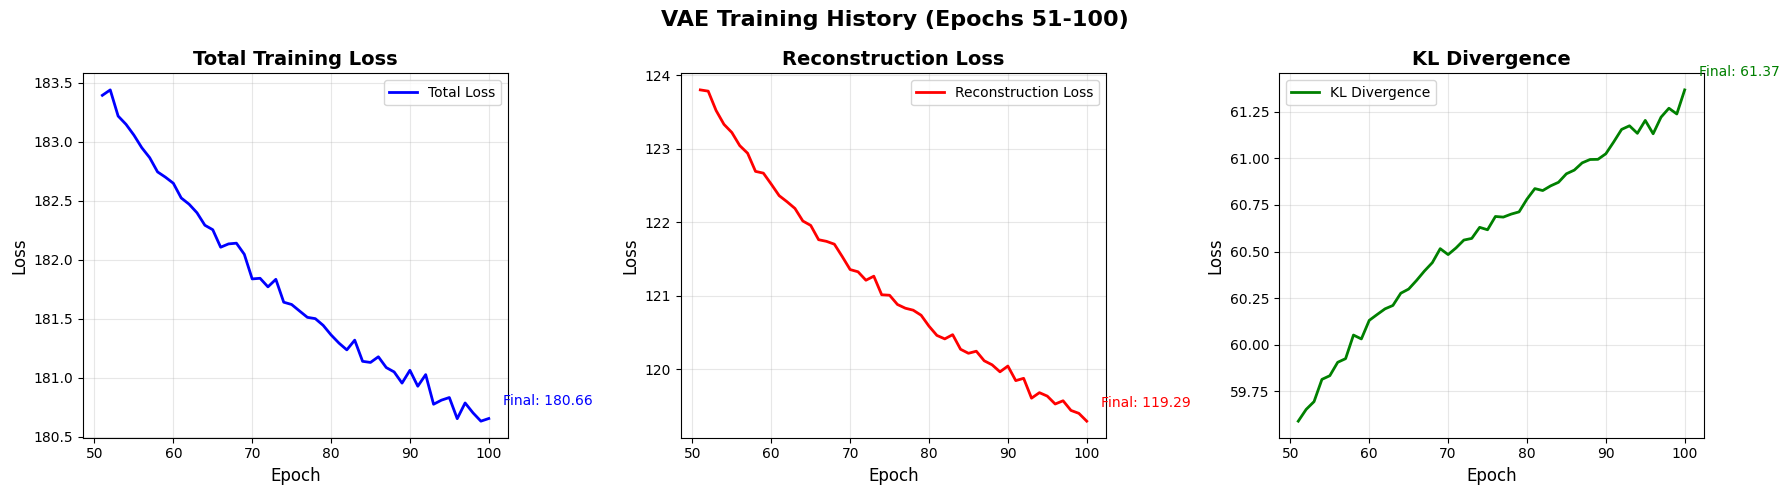


СТАТИСТИКА ОБУЧЕНИЯ:
Всего эпох: 50
Диапазон эпох: 51 - 100
Начальная общая ошибка: 183.39
Финальная общая ошибка: 180.66
Изменение общей ошибки: 2.74 (1.5%)
Финальная ошибка реконструкции: 119.29
Финальная KL-дивергенция: 61.37


In [13]:
plot_training_history(history_file='./vae_weights/training_history.pt')

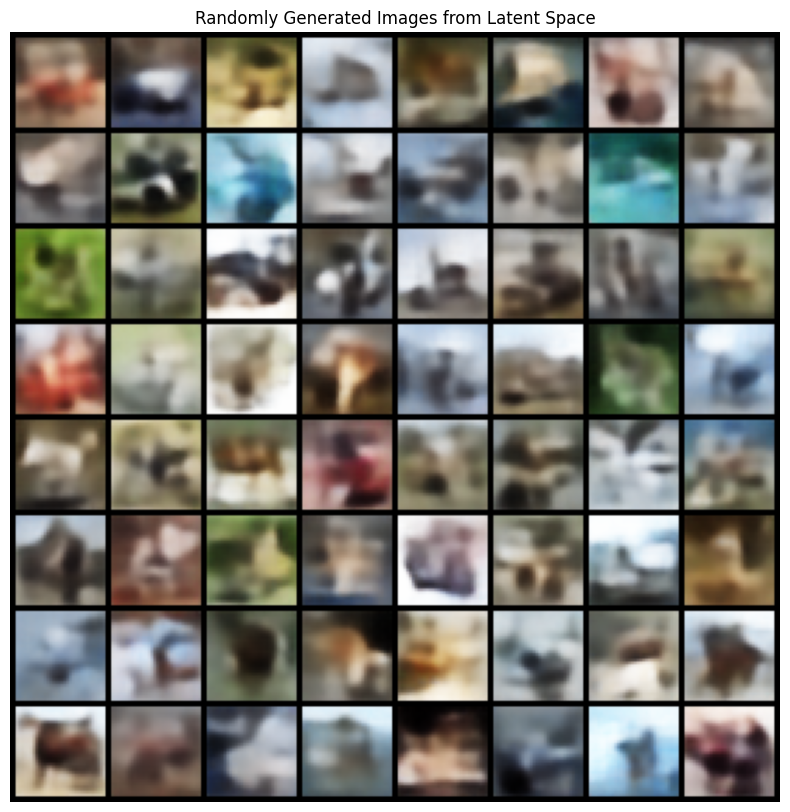

Final generated images saved to ./vae_outputs/final_generation.png


In [ ]:
# Здесь тот же код, что и был выше

model.eval()
with torch.no_grad():
    # Генерируем 64 новые картинки
    sample_z = torch.randn(64, latent_dim).to(device)
    generated_images = model.decode(sample_z)

    # Визуализируем их
    grid = make_grid(generated_images, nrow=8, normalize=True).cpu().numpy()
    grid = np.transpose(grid, (1, 2, 0))

    plt.figure(figsize=(10, 10))
    plt.imshow(np.clip(grid, 0, 1))
    plt.axis('off')
    plt.title('Randomly Generated Images from Latent Space')
    plt.show()

    # Сохраняем их
    save_image(generated_images, './vae_outputs/final_generation.png', nrow=8, normalize=True)
    print("Final generated images saved to ./vae_outputs/final_generation.png")